In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [4]:
!pip install dagshub mlflow -q

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay

import mlflow
import mlflow.sklearn
import dagshub
dagshub.init(repo_owner='lbegi23', repo_name='IEEE-CIS-Fraud-Detection', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=f0d594f4-3e50-4394-b814-c6a1dd938540&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=398142c22da8add7f7885f6b3c19a004ba0fbd6d23be15097ab4d2007b06bbd3




Output()

Accessing as lbegi23

Initialized MLflow to track repo "lbegi23/IEEE-CIS-Fraud-Detection"

Repository lbegi23/IEEE-CIS-Fraud-Detection initialized!

In [5]:
transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

df = transaction.merge(identity, on='TransactionID', how='left')

print(df.shape)
print(df['isFraud'].value_counts(normalize=True))

(590540, 434)
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


In [6]:
X = df.drop(columns=['isFraud', 'TransactionID'])
y = df['isFraud']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train:      {X_train.shape[0]} rows ({y_train.mean():.4f} fraud rate)")
print(f"Validation: {X_val.shape[0]} rows ({y_val.mean():.4f} fraud rate)")
print(f"Test:       {X_test.shape[0]} rows ({y_test.mean():.4f} fraud rate)")

Train:      413378 rows (0.0350 fraud rate)
Validation: 88581 rows (0.0350 fraud rate)
Test:       88581 rows (0.0350 fraud rate)


# EDA

In [7]:
null_pct = X_train.isnull().mean().sort_values(ascending=False)
print("Columns with >50% nulls:")
print(null_pct[null_pct > 0.5].to_string())

print(f"\nNumeric columns:     {X_train.select_dtypes(include='number').shape[1]}")
print(f"Categorical columns: {X_train.select_dtypes(exclude='number').shape[1]}")

cat_cols = X_train.select_dtypes(exclude='number').columns
print("\nCategorical columns and unique value counts:")
print(X_train[cat_cols].nunique().sort_values(ascending=False).to_string())

Columns with >50% nulls:
id_24            0.991908
id_25            0.991240
id_07            0.991224
id_08            0.991224
id_21            0.991209
id_26            0.991202
id_23            0.991194
id_27            0.991194
id_22            0.991194
dist2            0.936182
D7               0.934068
id_18            0.923291
D13              0.894622
D14              0.894126
D12              0.889890
id_03            0.887326
id_04            0.887326
D6               0.875542
id_33            0.875511
id_10            0.872543
D9               0.872543
id_09            0.872543
D8               0.872543
id_30            0.868283
id_32            0.868244
id_34            0.867874
id_14            0.864132
V163             0.860931
V142             0.860931
V141             0.860931
V161             0.860931
V162             0.860931
V156             0.860931
V139             0.860931
V155             0.860931
V148             0.860931
V138             0.860931
V154         

# Cleaning

In [8]:
high_null_cols = X_train.columns[X_train.isnull().mean() > 0.5].tolist()
print(f"Dropping {len(high_null_cols)} high-null columns")

high_cardinality_cols = ['DeviceInfo', 'id_33', 'id_31', 'id_30']

cols_to_drop = list(set(high_null_cols + high_cardinality_cols))

X_train_clean = X_train.drop(columns=cols_to_drop)
X_val_clean   = X_val.drop(columns=cols_to_drop)
X_test_clean  = X_test.drop(columns=cols_to_drop)

print(f"Shape after cleaning: {X_train_clean.shape}")

cat_cols = X_train_clean.select_dtypes(exclude='number').columns.tolist()
print(f"\nRemaining categorical columns ({len(cat_cols)}): {cat_cols}")

Dropping 214 high-null columns
Shape after cleaning: (413378, 218)

Remaining categorical columns (9): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M6']


# Feature Engineering

In [9]:
X_train_clean['TransactionAmt_log'] = np.log1p(X_train_clean['TransactionAmt'])
X_val_clean['TransactionAmt_log']   = np.log1p(X_val_clean['TransactionAmt'])
X_test_clean['TransactionAmt_log']  = np.log1p(X_test_clean['TransactionAmt'])

X_train_clean['TransactionAmt_cents'] = X_train_clean['TransactionAmt'] % 1
X_val_clean['TransactionAmt_cents']   = X_val_clean['TransactionAmt'] % 1
X_test_clean['TransactionAmt_cents']  = X_test_clean['TransactionAmt'] % 1

for df_ in [X_train_clean, X_val_clean, X_test_clean]:
    df_['hour'] = (df_['TransactionDT'] // 3600) % 24
    df_['day']  = (df_['TransactionDT'] // (3600 * 24)) % 7

print("New features added: TransactionAmt_log, TransactionAmt_cents, hour, day")
print(X_train_clean[['TransactionAmt', 'TransactionAmt_log', 'TransactionAmt_cents', 'hour', 'day']].head())

New features added: TransactionAmt_log, TransactionAmt_cents, hour, day
        TransactionAmt  TransactionAmt_log  TransactionAmt_cents  hour  day
335947          71.500            4.283587                 0.500    18    4
334070          34.500            3.569533                 0.500     1    4
551523          70.702            4.272519                 0.702    17    0
159780          47.950            3.890799                 0.950    21    3
270154          39.000            3.688879                 0.000    20    5


# Feature Selection

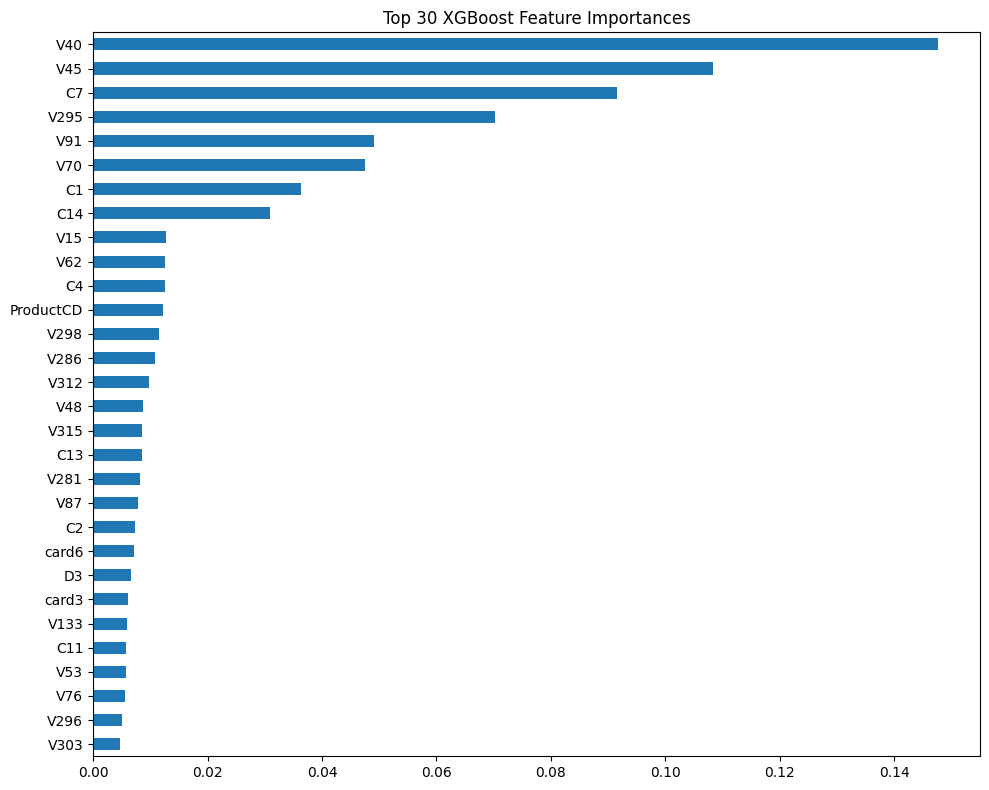

Features kept: 165 / 222


In [10]:
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

num_cols_sel = X_train_clean.select_dtypes(include='number').columns.tolist()
cat_cols_sel = X_train_clean.select_dtypes(exclude='number').columns.tolist()

num_imputer_fs = SimpleImputer(strategy='median')
cat_imputer_fs = SimpleImputer(strategy='most_frequent')
encoder_fs     = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_num_fs = num_imputer_fs.fit_transform(X_train_clean[num_cols_sel])
X_train_cat_fs = encoder_fs.fit_transform(cat_imputer_fs.fit_transform(X_train_clean[cat_cols_sel]))
X_train_fs     = np.hstack([X_train_num_fs, X_train_cat_fs])

selector = XGBClassifier(n_estimators=50, max_depth=5, n_jobs=-1, random_state=42, verbosity=0)
selector.fit(X_train_fs, y_train)

feature_names = num_cols_sel + cat_cols_sel
importances   = pd.Series(selector.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(30).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 30 XGBoost Feature Importances')
plt.tight_layout()
plt.show()

selected_features = importances[importances > 0].index.tolist()
print(f"Features kept: {len(selected_features)} / {X_train_clean.shape[1]}")

X_train_sel = X_train_clean[selected_features]
X_val_sel   = X_val_clean[selected_features]
X_test_sel  = X_test_clean[selected_features]

# Model

In [11]:
from xgboost import XGBClassifier

num_cols_sel = X_train_sel.select_dtypes(include='number').columns.tolist()
cat_cols_sel = X_train_sel.select_dtypes(exclude='number').columns.tolist()

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

print("Model defined:", model)
print(f"Numeric features:     {len(num_cols_sel)}")
print(f"Categorical features: {len(cat_cols_sel)}")

scale_pos_weight: 27.58
Model defined: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)
Numeric features:     157
Categorical features: 8


# Training

## Baseline

In [12]:
from sklearn.metrics import roc_auc_score, classification_report

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
encoder     = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_num = num_imputer.fit_transform(X_train_sel[num_cols_sel])
X_val_num   = num_imputer.transform(X_val_sel[num_cols_sel])

X_train_cat = encoder.fit_transform(cat_imputer.fit_transform(X_train_sel[cat_cols_sel]))
X_val_cat   = encoder.transform(cat_imputer.transform(X_val_sel[cat_cols_sel]))

X_train_processed = np.hstack([X_train_num, X_train_cat])
X_val_processed   = np.hstack([X_val_num, X_val_cat])

mlflow.set_experiment("xgboost")

with mlflow.start_run(run_name="XGB_baseline"):
    model.fit(X_train_processed, y_train)

    val_preds = model.predict(X_val_processed)
    val_proba = model.predict_proba(X_val_processed)[:, 1]
    auc       = roc_auc_score(y_val, val_proba)

    mlflow.log_params({
        'model': 'XGBClassifier',
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.05,
        'scale_pos_weight': round(scale_pos_weight, 2),
        'feature_selection': 'XGB_importances',
    })
    mlflow.log_metric('val_roc_auc', auc)

    print(f"Validation ROC-AUC: {auc:.4f}")
    print(classification_report(y_val, val_preds, target_names=['legit', 'fraud']))

Validation ROC-AUC: 0.9298
              precision    recall  f1-score   support

       legit       0.99      0.91      0.95     85481
       fraud       0.24      0.79      0.37      3100

    accuracy                           0.90     88581
   macro avg       0.61      0.85      0.66     88581
weighted avg       0.97      0.90      0.93     88581

🏃 View run XGB_baseline at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/a204793c7e1f46f8b91a54d61688402b
🧪 View experiment at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


## Undersampling

In [13]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_processed, y_train)

mlflow.set_experiment("xgboost")

with mlflow.start_run(run_name="XGB_undersampling"):
    model_us = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )
    model_us.fit(X_train_resampled, y_train_resampled)

    val_preds_us = model_us.predict(X_val_processed)
    val_proba_us = model_us.predict_proba(X_val_processed)[:, 1]
    auc_us       = roc_auc_score(y_val, val_proba_us)

    mlflow.log_params({
        'model': 'XGBClassifier',
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.05,
        'undersampling': 'RandomUnderSampler',
        'feature_selection': 'XGB_importances',
    })
    mlflow.log_metric('val_roc_auc', auc_us)

    print(f"Validation ROC-AUC: {auc_us:.4f}")
    print(classification_report(y_val, val_preds_us, target_names=['legit', 'fraud']))

Validation ROC-AUC: 0.9232
              precision    recall  f1-score   support

       legit       0.99      0.88      0.93     85481
       fraud       0.20      0.81      0.32      3100

    accuracy                           0.88     88581
   macro avg       0.59      0.84      0.62     88581
weighted avg       0.96      0.88      0.91     88581

🏃 View run XGB_undersampling at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/96e03c9eceab49c28e5c598db3ea5bca
🧪 View experiment at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


# Testing

2026/05/04 11:45:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 11:45:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'xgboost-baseline' already exists. Creating a new version of this model...
2026/05/04 11:46:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgboost-baseline, version 2
Created version '2' of model 'xgboost-baseline'.


Test ROC-AUC: 0.9344
              precision    recall  f1-score   support

       legit       0.99      0.91      0.95     85482
       fraud       0.24      0.81      0.37      3099

    accuracy                           0.90     88581
   macro avg       0.62      0.86      0.66     88581
weighted avg       0.97      0.90      0.93     88581



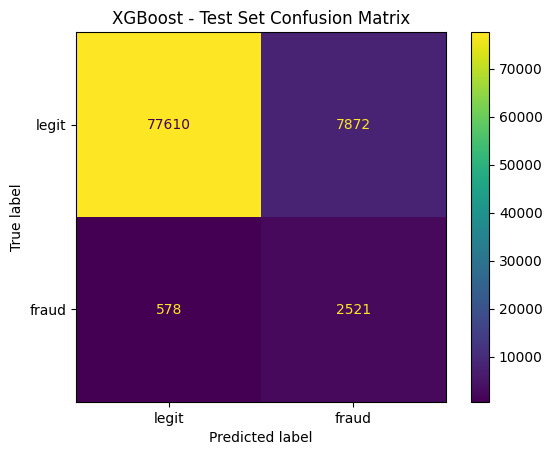

🏃 View run XGB_test_evaluation at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/ff19e48ad17b4a48805d8fa97d5e8442
🧪 View experiment at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


In [14]:
X_test_num = num_imputer.transform(X_test_sel[num_cols_sel])
X_test_cat = encoder.transform(cat_imputer.transform(X_test_sel[cat_cols_sel]))
X_test_processed = np.hstack([X_test_num, X_test_cat])

test_proba = model.predict_proba(X_test_processed)[:, 1]
test_preds = model.predict(X_test_processed)
test_auc   = roc_auc_score(y_test, test_proba)

mlflow.set_experiment("xgboost")

with mlflow.start_run(run_name="XGB_test_evaluation"):
    mlflow.log_metric("test_roc_auc", test_auc)
    mlflow.sklearn.log_model(model, "model", registered_model_name="xgboost-baseline")

    print(f"Test ROC-AUC: {test_auc:.4f}")
    print(classification_report(y_test, test_preds, target_names=['legit', 'fraud']))

    ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=['legit', 'fraud'])
    plt.title('XGBoost - Test Set Confusion Matrix')
    plt.show()

In [15]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':  [200, 300, 500],
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    verbose=2
)

search.fit(X_train_processed, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV AUC: {search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=8, n_estimators=500, subsample=0.7; total time=  48.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=8, n_estimators=500, subsample=0.7; total time=  48.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=8, n_estimators=500, subsample=0.7; total time=  48.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=0.7; total time=  27.9s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=0.7; total time=  27.8s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=0.7; total time=  28.1s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=500, subsample=1.0; total time=  29.2s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=500, subsample=1.0; total time=  29.5s
[CV] END cols

In [16]:
mlflow.set_experiment("xgboost")

with mlflow.start_run(run_name="XGB_tuned"):
    model_tuned = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=1.0,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )
    model_tuned.fit(X_train_processed, y_train)

    val_preds = model_tuned.predict(X_val_processed)
    val_proba = model_tuned.predict_proba(X_val_processed)[:, 1]
    auc       = roc_auc_score(y_val, val_proba)

    mlflow.log_params({
        'model': 'XGBClassifier',
        'n_estimators': 300,
        'max_depth': 8,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 1.0,
        'scale_pos_weight': round(scale_pos_weight, 2),
        'tuning': 'RandomizedSearchCV',
    })
    mlflow.log_metric('val_roc_auc', auc)

    print(f"Validation ROC-AUC: {auc:.4f}")
    print(classification_report(y_val, val_preds, target_names=['legit', 'fraud']))

Validation ROC-AUC: 0.9591
              precision    recall  f1-score   support

       legit       0.99      0.96      0.98     85481
       fraud       0.45      0.80      0.58      3100

    accuracy                           0.96     88581
   macro avg       0.72      0.88      0.78     88581
weighted avg       0.97      0.96      0.96     88581

🏃 View run XGB_tuned at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/bcfac640bde44544b9e93b9b8d70b6c0
🧪 View experiment at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


2026/05/04 12:06:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'xgboost-tuned'.
2026/05/04 12:06:28 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgboost-tuned, version 1
Created version '1' of model 'xgboost-tuned'.


Test ROC-AUC: 0.9607
              precision    recall  f1-score   support

       legit       0.99      0.97      0.98     85482
       fraud       0.46      0.82      0.59      3099

    accuracy                           0.96     88581
   macro avg       0.73      0.89      0.78     88581
weighted avg       0.97      0.96      0.97     88581



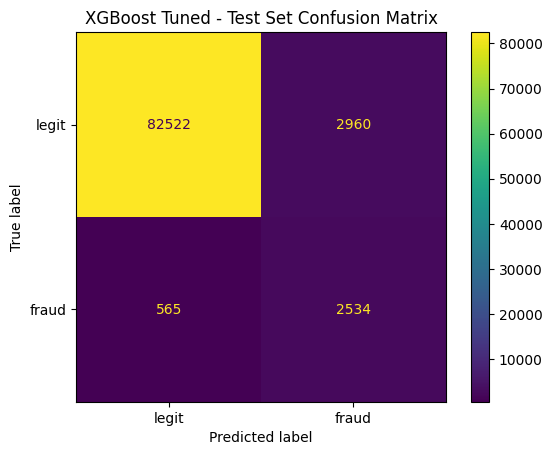

🏃 View run XGB_tuned_test_evaluation at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/efd076f31131462fbe9453805aa67b6a
🧪 View experiment at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


In [17]:
test_proba = model_tuned.predict_proba(X_test_processed)[:, 1]
test_preds = model_tuned.predict(X_test_processed)
test_auc   = roc_auc_score(y_test, test_proba)

mlflow.set_experiment("xgboost")

with mlflow.start_run(run_name="XGB_tuned_test_evaluation"):
    mlflow.log_metric("test_roc_auc", test_auc)
    mlflow.xgboost.log_model(model_tuned, "model", registered_model_name="xgboost-tuned")

    print(f"Test ROC-AUC: {test_auc:.4f}")
    print(classification_report(y_test, test_preds, target_names=['legit', 'fraud']))

    ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=['legit', 'fraud'])
    plt.title('XGBoost Tuned - Test Set Confusion Matrix')
    plt.show()

# Pipeline

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols_sel = X_train_sel.select_dtypes(include='number').columns.tolist()
cat_cols_sel = X_train_sel.select_dtypes(exclude='number').columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols_sel),
    ('cat', categorical_transformer, cat_cols_sel)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=1.0,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        random_state=42,
        verbosity=0
    ))
])

mlflow.set_experiment("xgboost")

with mlflow.start_run(run_name="XGB_tuned_pipeline"):
    pipeline.fit(X_train_sel, y_train)

    val_proba = pipeline.predict_proba(X_val_sel)[:, 1]
    val_preds = pipeline.predict(X_val_sel)
    auc       = roc_auc_score(y_val, val_proba)

    mlflow.log_params({
        'model': 'XGBClassifier',
        'n_estimators': 300,
        'max_depth': 8,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 1.0,
        'scale_pos_weight': round(scale_pos_weight, 2),
        'pipeline': True,
    })
    mlflow.log_metric('val_roc_auc', auc)
    mlflow.sklearn.log_model(pipeline, "pipeline", registered_model_name="xgboost-tuned-pipeline")

    print(f"Validation ROC-AUC: {auc:.4f}")
    print(classification_report(y_val, val_preds, target_names=['legit', 'fraud']))

2026/05/04 12:08:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 12:08:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'xgboost-tuned-pipeline'.
2026/05/04 12:08:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgboost-tuned-pipeline, version 1
Created version '1' of model 'xgboost-tuned-pipeline'.


Validation ROC-AUC: 0.9591
              precision    recall  f1-score   support

       legit       0.99      0.96      0.98     85481
       fraud       0.45      0.80      0.58      3100

    accuracy                           0.96     88581
   macro avg       0.72      0.88      0.78     88581
weighted avg       0.97      0.96      0.96     88581

🏃 View run XGB_tuned_pipeline at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/699d4d341d3a4022ae378fe48ff312e6
🧪 View experiment at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


2026/05/04 12:09:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 12:09:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'xgboost-tuned-pipeline' already exists. Creating a new version of this model...
2026/05/04 12:09:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgboost-tuned-pipeline, version 2
Created version '2' of model 'xgboost-tuned-pipeline'.


Test ROC-AUC: 0.9607
              precision    recall  f1-score   support

       legit       0.99      0.97      0.98     85482
       fraud       0.46      0.82      0.59      3099

    accuracy                           0.96     88581
   macro avg       0.73      0.89      0.78     88581
weighted avg       0.97      0.96      0.97     88581



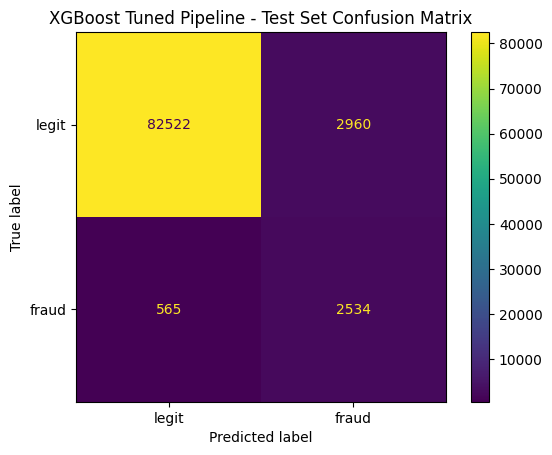

🏃 View run XGB_tuned_pipeline_test at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/737ae387fa6340b39e2b27a135e1c7f9
🧪 View experiment at: https://dagshub.com/lbegi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


In [19]:
test_proba = pipeline.predict_proba(X_test_sel)[:, 1]
test_preds = pipeline.predict(X_test_sel)
test_auc   = roc_auc_score(y_test, test_proba)

mlflow.set_experiment("xgboost")

with mlflow.start_run(run_name="XGB_tuned_pipeline_test"):
    mlflow.log_metric("test_roc_auc", test_auc)
    mlflow.sklearn.log_model(pipeline, "pipeline", registered_model_name="xgboost-tuned-pipeline")

    print(f"Test ROC-AUC: {test_auc:.4f}")
    print(classification_report(y_test, test_preds, target_names=['legit', 'fraud']))

    ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=['legit', 'fraud'])
    plt.title('XGBoost Tuned Pipeline - Test Set Confusion Matrix')
    plt.show()